<a href="https://colab.research.google.com/github/Nikralet/General/blob/main/%D0%9B%D0%90%D0%91%D0%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_2656/4229197632.py:25: RuntimeWarning: divide by zero encountered in scalar divide
  dp1 = (-p1 - np.sin(phi1) - (phi1 - phi_x)/beta_L - (phi1 - phi2 - phi_in)/beta_q) / beta_c
/tmp/ipykernel_2656/4229197632.py:26: RuntimeWarning: divide by zero encountered in scalar divide
  dp2 = (-p2 - np.sin(phi2) - (phi2 + phi_x)/beta_L + (phi1 - phi2 - phi_in)/beta_q) / beta_c
/tmp/ipykernel_2656/4229197632.py:44: ODEintWarning: Illegal input detected (internal error). Run with full_output = 1 to get quantitative information.
  sol = odeint(aqfp_rhs_c, y0, t_eval, args=(params,), rtol=1e-6, atol=1e-8)


Iter 0: β_L=0.3881, β_q=1.5954, β_c=0.1000, A_x=0.1000, φ_dc=-0.5000, |<iq>|=0.32980
Iter 1: β_L=0.3758, β_q=1.5908, β_c=0.1000, A_x=0.1001, φ_dc=-0.5000, |<iq>|=0.33523
Iter 2: β_L=0.3631, β_q=1.5860, β_c=0.1000, A_x=0.1001, φ_dc=-0.5000, |<iq>|=0.34101
Iter 3: β_L=0.3499, β_q=1.5811, β_c=0.1000, A_x=0.1001, φ_dc=-0.5000, |<iq>|=0.34718
Iter 4: β_L=0.3363, β_q=1.5760, β_c=0.1000, A_x=0.1002, φ_dc=-0.5000, |<iq>|=0.35378
Iter 5: β_L=0.3221, β_q=1.5708, β_c=0.1000, A_x=0.1002, φ_dc=-0.5000, |<iq>|=0.36088
Iter 6: β_L=0.3073, β_q=1.5655, β_c=0.1000, A_x=0.1002, φ_dc=-0.5000, |<iq>|=0.36853
Iter 7: β_L=0.2919, β_q=1.5599, β_c=0.1000, A_x=0.1003, φ_dc=-0.5000, |<iq>|=0.37682
Iter 8: β_L=0.2757, β_q=1.5541, β_c=0.1000, A_x=0.1003, φ_dc=-0.5000, |<iq>|=0.38586
Iter 9: β_L=0.2587, β_q=1.5482, β_c=0.1000, A_x=0.1003, φ_dc=-0.5000, |<iq>|=0.39575
Iter 10: β_L=0.2408, β_q=1.5419, β_c=0.1000, A_x=0.1004, φ_dc=-0.5000, |<iq>|=0.40666
Iter 11: β_L=0.2218, β_q=1.5354, β_c=0.1000, A_x=0.1004, φ_dc=-0

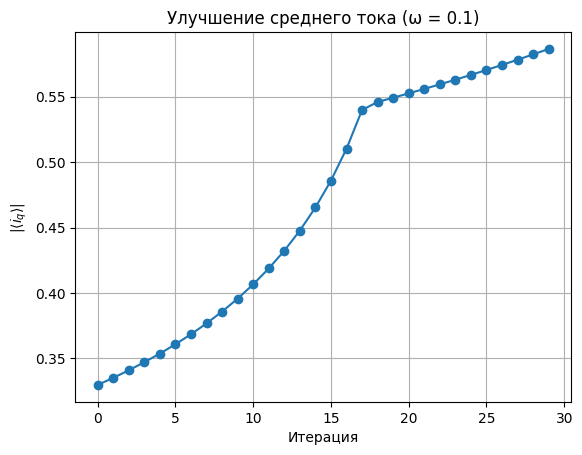

In [7]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# =============================================================================
# РАСШИРЕННАЯ МОДЕЛЬ AQFP (с ёмкостью переходов β_c)
# =============================================================================
# Параметры: beta_L, beta_q, beta_c, Ax, omega, phi_dc, phi_in
# Возбуждение: phi_x(t) = Ax * sin(omega * t) + phi_dc
# Уравнения (RCSJ с индуктивностями, второй порядок):
#   dφ1/dt = p1
#   dφ2/dt = p2
#   dp1/dt = [-p1 - sin φ1 - (φ1 - φ_x)/β_L - (φ1 - φ2 - φ_in)/β_q] / β_c
#   dp2/dt = [-p2 - sin φ2 - (φ2 + φ_x)/β_L + (φ1 - φ2 - φ_in)/β_q] / β_c
# Выход: i_q = (φ1 - φ2 - φ_in) / β_q
# =============================================================================

def aqfp_rhs_c(state, t, params):
    phi1, phi2, p1, p2 = state
    beta_L, beta_q, beta_c, Ax, omega, phi_dc, phi_in = params
    phi_x = Ax * np.sin(omega * t) + phi_dc

    dphi1 = p1
    dphi2 = p2
    dp1 = (-p1 - np.sin(phi1) - (phi1 - phi_x)/beta_L - (phi1 - phi2 - phi_in)/beta_q) / beta_c
    dp2 = (-p2 - np.sin(phi2) - (phi2 + phi_x)/beta_L + (phi1 - phi2 - phi_in)/beta_q) / beta_c
    return [dphi1, dphi2, dp1, dp2]

def output_current(state, params):
    phi1, phi2, p1, p2 = state
    beta_L, beta_q, beta_c, Ax, omega, phi_dc, phi_in = params
    return (phi1 - phi2 - phi_in) / beta_q

# =============================================================================
# ИНТЕГРИРОВАНИЕ И СРЕДНЕЕ ЗНАЧЕНИЕ
# =============================================================================
def simulate_and_average_c(params, n_periods=50, n_points=200, transient=0.3):
    beta_L, beta_q, beta_c, Ax, omega, phi_dc, phi_in = params
    T = 2 * np.pi / omega
    t_max = n_periods * T
    t_eval = np.linspace(0, t_max, n_periods * n_points)

    y0 = [0.0, 0.0, 0.0, 0.0]  # φ1, φ2, p1, p2
    sol = odeint(aqfp_rhs_c, y0, t_eval, args=(params,), rtol=1e-6, atol=1e-8)
    phi1_arr, phi2_arr = sol[:, 0], sol[:, 1]
    iq_arr = (phi1_arr - phi2_arr - phi_in) / beta_q

    n_trans = int(transient * len(t_eval))
    return np.mean(iq_arr[n_trans:])

# =============================================================================
# ГРАДИЕНТНЫЙ СПУСК (варьируются β_L, β_q, A_x, φ_dc, β_c) при Φ_in=0
# =============================================================================
def gradient_descent(params_init, lr=0.03, delta=0.1, max_iter=40, tol=1e-4):
    params = np.array(params_init, dtype=float)  # 7 элементов: β_L, β_q, β_c, A_x, ω, φ_dc, φ_in
    # Фиксируем ω (индекс 4) и φ_in (индекс 6)
    var_idx = [0, 1, 2, 3, 5]  # β_L, β_q, β_c, A_x, φ_dc
    labels = ['β_L', 'β_q', 'β_c', 'A_x', 'φ_dc']

    def objective(var_vals):
        p = params.copy()
        for i, idx in enumerate(var_idx):
            p[idx] = var_vals[i]
        p[4] = 0.1      # фиксированная ω
        p[6] = 0.0      # φ_in = 0
        return -abs(simulate_and_average_c(tuple(p), n_periods=40))

    history = []
    for it in range(max_iter):
        cur = np.array([params[i] for i in var_idx])
        val = objective(cur)
        history.append(-val)

        grad = np.zeros(len(var_idx))
        for i in range(len(var_idx)):
            pert = np.zeros(len(var_idx))
            pert[i] = delta
            grad[i] = (objective(cur + pert) - objective(cur - pert)) / (2*delta)

        new = cur - lr * grad
        # Ограничения
        bounds = [(0.1, 2.0), (0.1, 5.0), (0.1, 3.0), (0.1, 5.0), (-0.5, 0.5)]
        for i in range(len(new)):
            low, high = bounds[i]
            new[i] = max(low, min(high, new[i]))

        for i, idx in enumerate(var_idx):
            params[idx] = new[i]

        print(f"Iter {it}: " + ", ".join([f"{l}={new[i]:.4f}" for i,l in enumerate(labels)]) +
              f", |<iq>|={-val:.5f}")

        if np.linalg.norm(grad) < tol:
            print("Градиент мал, остановка.")
            break

    return params, history

# =============================================================================
# ДЕМОНСТРАЦИЯ
# =============================================================================
if __name__ == "__main__":
    # Начальные параметры (β_L, β_q, β_c, A_x, ω, φ_dc, φ_in)
    init = [0.4, 1.6, 0.1, 0.1, 0.1, -0.5, 0.0]
    opt_params, hist = gradient_descent(init, lr=0.03, delta=0.1, max_iter=30)

    print("\nОптимальные параметры (β_L, β_q, β_c, A_x, ω=0.1, φ_dc, φ_in=0):")
    print([f"{opt_params[i]:.4f}" for i in range(7)])

    # График сходимости (улучшения среднего тока)
    plt.figure()
    plt.plot(hist, 'o-')
    plt.xlabel('Итерация')
    plt.ylabel(r'$|\langle i_q \rangle|$')
    plt.title('Улучшение среднего тока (ω = 0.1)')
    plt.grid(True)
    plt.show()